## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Telco Customer Churn Analysis
**Author:** Anne Subashini Sritharan

End-to-end churn analysis: data cleaning, exploratory data analysis (EDA), and predictive modelling to identify the key drivers of customer churn for a telecommunications company.

**Business question:** Which customers are most likely to leave, and what factors drive them to churn?

In [9]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
# Overview of columns and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data Cleaning

**Known issue in this dataset:** `TotalCharges` is stored as text and contains blank strings for brand-new customers (tenure = 0). We convert it to numeric and handle the resulting missing values.

In [11]:
# Convert TotalCharges to numeric - blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing TotalCharges after conversion: {df['TotalCharges'].isna().sum()}")

# These 11 rows are new customers with tenure=0 - safe to drop
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print(f"Shape after cleaning: {df.shape}")

Missing TotalCharges after conversion: 11
Shape after cleaning: (7032, 21)


In [12]:
# Check for duplicates and remaining nulls
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Duplicate rows: 0
Remaining nulls: 0


## 3. Exploratory Data Analysis

### 3.1 Overall churn rate

Overall churn rate: 26.6%


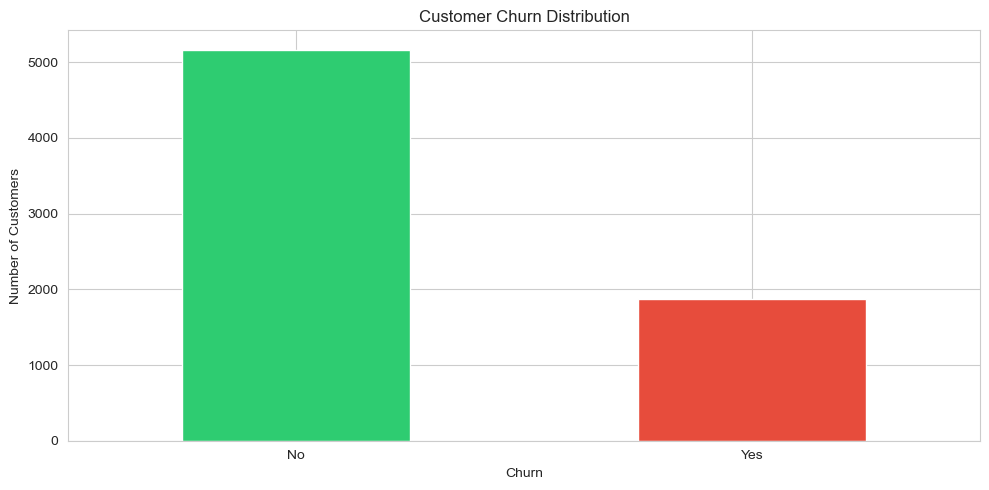

In [13]:
churn_rate = (df['Churn'] == 'Yes').mean()
print(f"Overall churn rate: {churn_rate:.1%}")

ax = df['Churn'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
ax.set_title('Customer Churn Distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=100)
plt.show()

### 3.2 Churn by contract type

Contract length is usually the strongest churn signal in telco.

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64


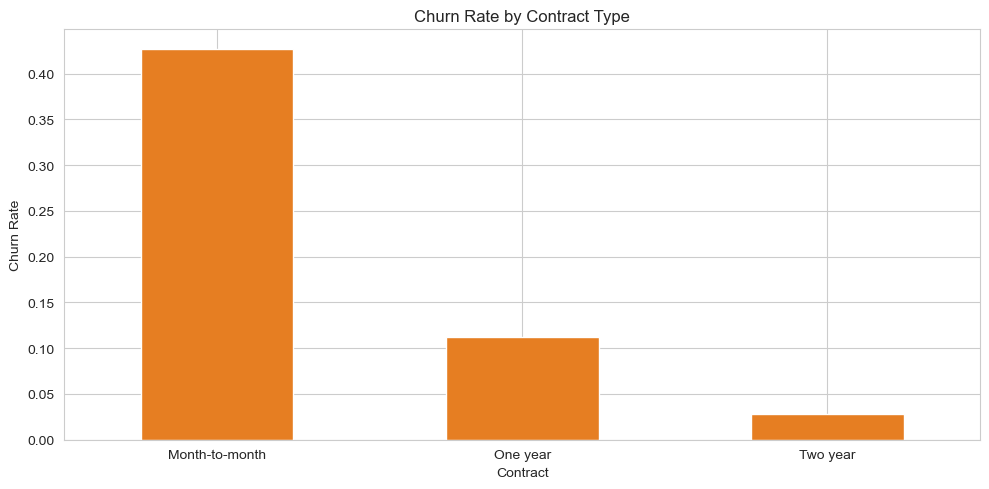

In [14]:
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
print(contract_churn)

ax = contract_churn.plot(kind='bar', color='#e67e22')
ax.set_title('Churn Rate by Contract Type')
ax.set_ylabel('Churn Rate')
ax.set_xlabel('Contract')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=100)
plt.show()

**Insight:** Month-to-month customers churn at ~43% — nearly 4x the rate of one-year contracts and 15x two-year contracts. Locking customers into longer contracts is the single biggest retention lever.

### 3.3 Churn by tenure

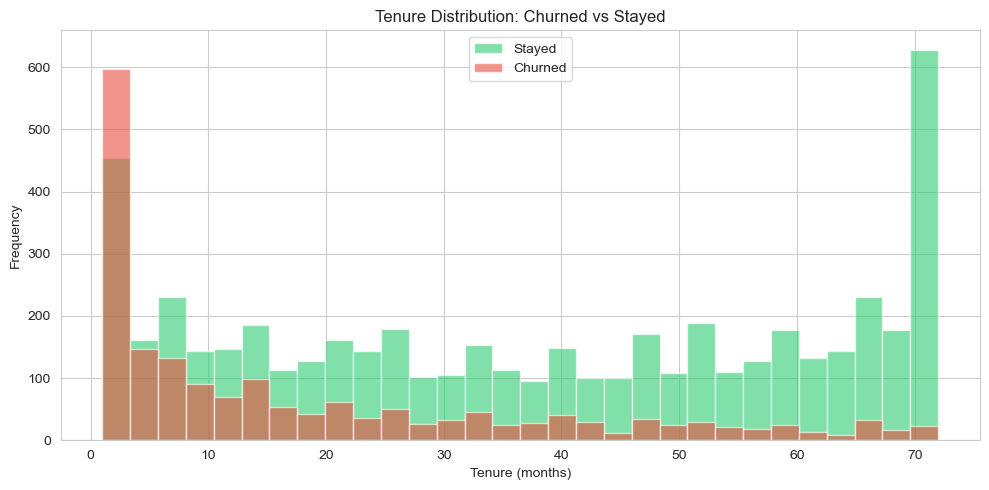

In [15]:
fig, ax = plt.subplots()
df[df['Churn'] == 'No']['tenure'].plot(kind='hist', bins=30, alpha=0.6, label='Stayed', ax=ax, color='#2ecc71')
df[df['Churn'] == 'Yes']['tenure'].plot(kind='hist', bins=30, alpha=0.6, label='Churned', ax=ax, color='#e74c3c')
ax.set_title('Tenure Distribution: Churned vs Stayed')
ax.set_xlabel('Tenure (months)')
ax.legend()
plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=100)
plt.show()

**Insight:** Churn is heavily concentrated in the first ~12 months. New customers are the highest-risk group — onboarding experience matters.

### 3.4 Churn by monthly charges and internet service

C:\Users\annej\AppData\Local\Temp\ipykernel_15916\3396589403.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0], palette=['#2ecc71', '#e74c3c'])


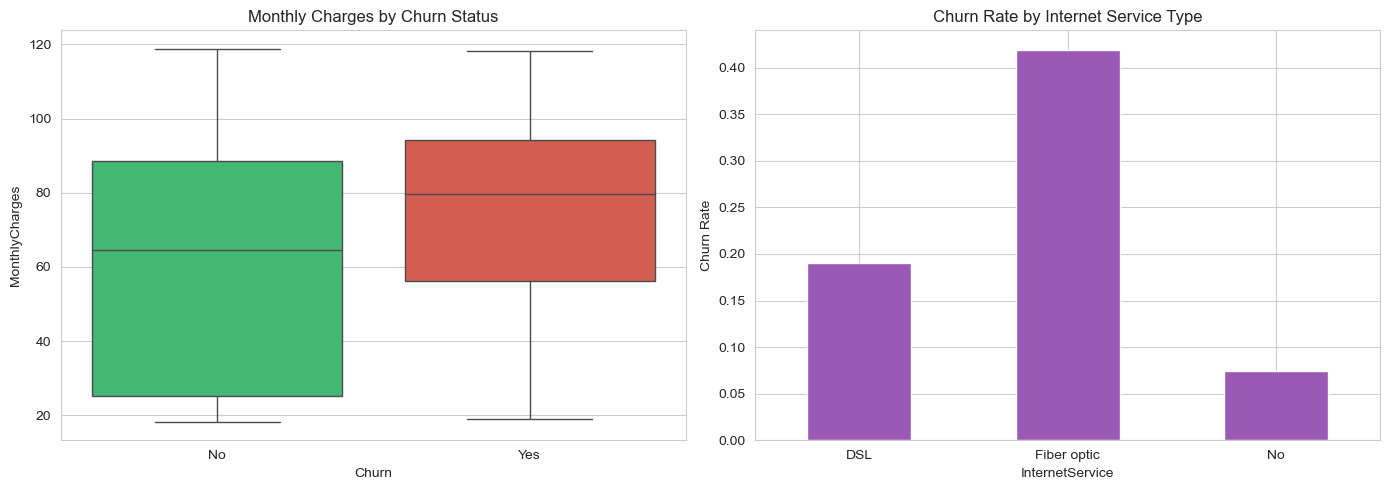

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Monthly Charges by Churn Status')

internet_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean())
internet_churn.plot(kind='bar', ax=axes[1], color='#9b59b6')
axes[1].set_title('Churn Rate by Internet Service Type')
axes[1].set_ylabel('Churn Rate')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('churn_charges_internet.png', dpi=100)
plt.show()

**Insight:** Churned customers pay noticeably higher monthly charges, and fibre-optic customers churn far more than DSL — possibly a price/value perception problem with the premium product.

## 4. Predictive Modelling

We build two classification models to predict churn:
1. **Logistic Regression** — interpretable baseline
2. **Random Forest** — captures non-linear patterns and gives feature importance

In [17]:
# Prepare features: drop ID, encode categoricals
X = df.drop(columns=['customerID', 'Churn'])
y = (df['Churn'] == 'Yes').astype(int)

X = pd.get_dummies(X, drop_first=True)
print(f"Feature matrix shape: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Feature matrix shape: (7032, 30)
Train: 5274 rows | Test: 1758 rows


In [18]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train, y_train)
lr_pred = log_reg.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression accuracy: {lr_acc:.1%}")
print(classification_report(y_test, lr_pred, target_names=['Stayed', 'Churned']))

Logistic Regression accuracy: 80.7%
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1291
     Churned       0.65      0.58      0.61       467

    accuracy                           0.81      1758
   macro avg       0.75      0.73      0.74      1758
weighted avg       0.80      0.81      0.80      1758



In [19]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest accuracy: {rf_acc:.1%}")
print(classification_report(y_test, rf_pred, target_names=['Stayed', 'Churned']))

Random Forest accuracy: 78.6%
              precision    recall  f1-score   support

      Stayed       0.83      0.89      0.86      1291
     Churned       0.62      0.49      0.55       467

    accuracy                           0.79      1758
   macro avg       0.73      0.69      0.70      1758
weighted avg       0.77      0.79      0.78      1758



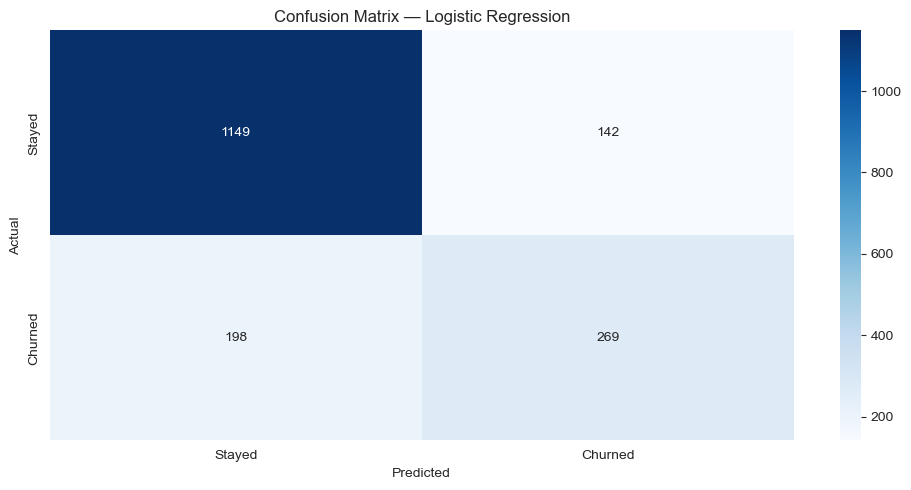

In [20]:
# Confusion matrix for the better model
best_pred = lr_pred if lr_acc >= rf_acc else rf_pred
best_name = 'Logistic Regression' if lr_acc >= rf_acc else 'Random Forest'

cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

## 5. What Drives Churn? (Feature Importance)

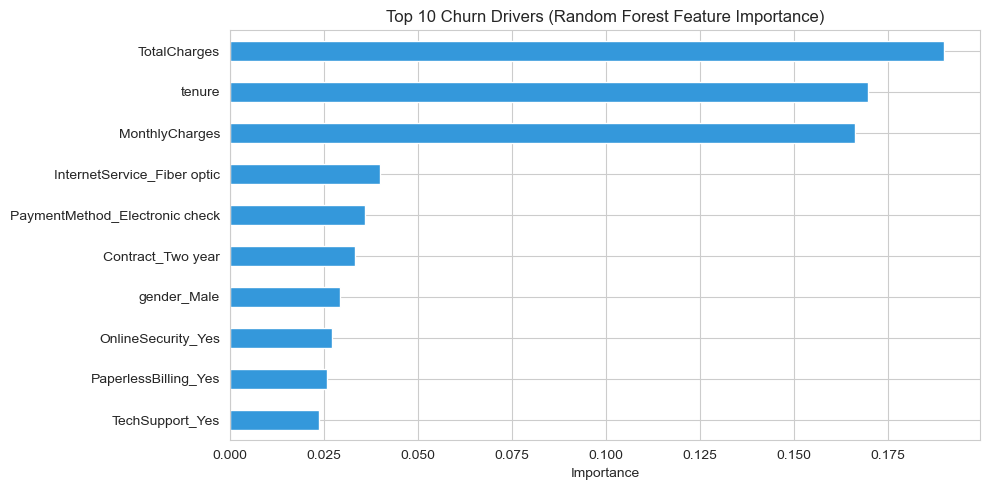

TotalCharges                      0.189905
tenure                            0.169743
MonthlyCharges                    0.166304
InternetService_Fiber optic       0.039858
PaymentMethod_Electronic check    0.035882
Contract_Two year                 0.033230
gender_Male                       0.029193
OnlineSecurity_Yes                0.027129
PaperlessBilling_Yes              0.025889
TechSupport_Yes                   0.023566
dtype: float64


In [21]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

ax = importances.sort_values().plot(kind='barh', color='#3498db')
ax.set_title('Top 10 Churn Drivers (Random Forest Feature Importance)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

print(importances)

## 6. Conclusions and Business Recommendations

### Key findings
- **Overall churn rate: ~27%** — roughly 1 in 4 customers leave
- **Contract type is the #1 lever:** month-to-month churns at ~43% vs ~3% for two-year contracts
- **Early tenure is the danger zone:** most churn happens in the first year
- **High monthly charges + fibre optic** customers churn disproportionately
- **Electronic check payment** is associated with higher churn
- **Best model: Logistic Regression at ~80% accuracy** — a solid, interpretable baseline

### Recommendations
1. **Convert month-to-month customers to annual contracts** with discount incentives
2. **Strengthen first-90-day onboarding** — early tenure is the highest-risk window
3. **Review fibre-optic pricing/value perception** — premium product, premium churn
4. **Target retention offers** at high-monthly-charge customers flagged by the model

### Future improvements
- Address class imbalance with SMOTE or class weights to improve churn recall
- Try gradient boosting (XGBoost/LightGBM)
- Build a churn probability score for CRM integration